In [ ]:
# =============================================
# STEP 1: Install required libraries
# =============================================
!pip install pandas statsmodels seaborn matplotlib openpyxl pingouin --quiet


In [ ]:
# =============================================
# STEP 2: Import libraries
# =============================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import pingouin as pg


In [ ]:
# --- STEP 1: Upload the Excel file ---
from google.colab import files
uploaded = files.upload() #adult_combined.xlsx

Saving adult_combined.xlsx to adult_combined (1).xlsx


In [ ]:
# =============================================
# STEP 3: Read Excel file
# =============================================
df = pd.read_excel("adult_combined.xlsx")
print("Data loaded successfully!")
display(df.head())


Data loaded successfully!


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


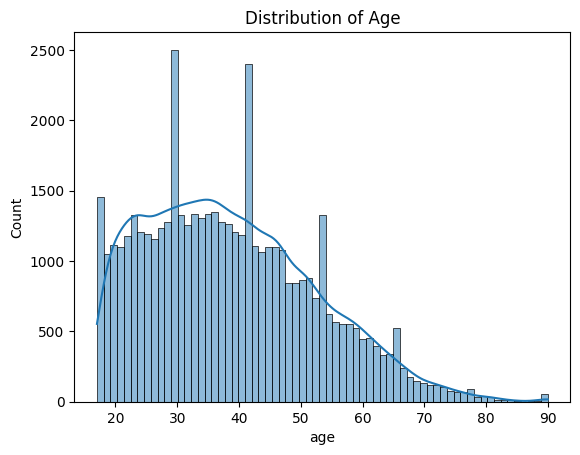

In [ ]:
# =============================================
# STEP 4: Quick EDA / Visualization
# =============================================
# Histogram of dependent variable
sns.histplot(df['age'], kde=True)
plt.title("Distribution of Age")
plt.show()

In [ ]:
print(df[df['sex'] == 'Male']['age'].mean())
print(df[df['sex'] == 'Female']['age'].mean())

39.49439509954058
36.92798913043478


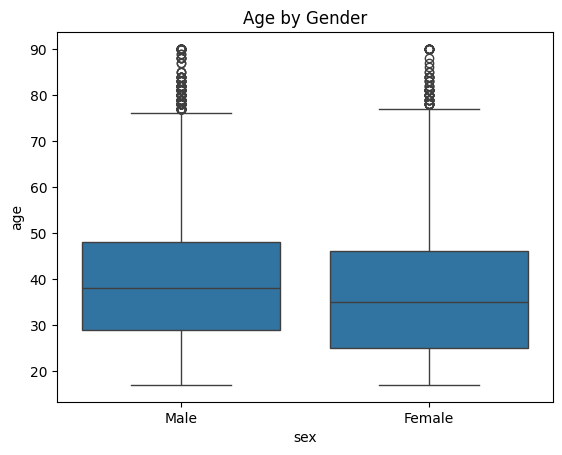

In [ ]:
# Boxplot of dependent variable vs categorical independent variable
sns.boxplot(x='sex', y='age', data=df)
plt.title("Age by Gender")
plt.show()

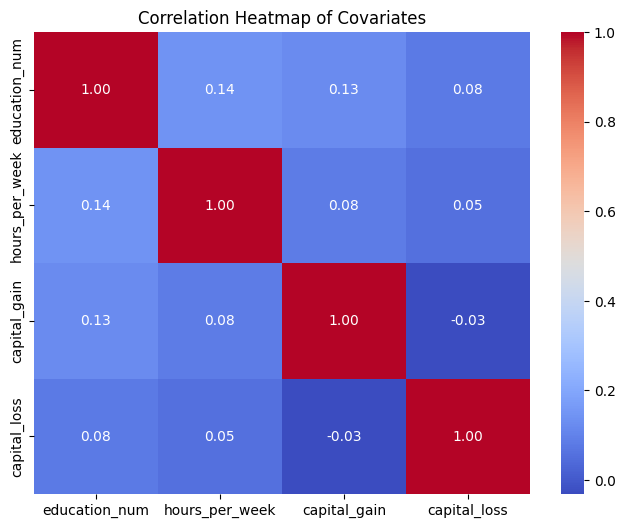

In [ ]:
# check for multicollinearity — covariates that are highly (r > 0.8) correlated
# List of covariates
covariates = ['education_num','hours_per_week','capital_gain','capital_loss']

# Compute correlation matrix
corr_matrix = df[covariates].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of Covariates")
plt.show()


In [ ]:
# =============================================
# STEP 5: Preprocessing
# =============================================
# Drop rows with missing values
df.dropna(inplace=True)


In [ ]:
# =============================================
# STEP 7: Fit ANCOVA model
# =============================================
# Dependent variable: age
# Independent variable: sex
# Covariates: education_num, hours_per_week, capital_gain, capital_loss

model = ols('age ~ C(sex) + education_num + hours_per_week + capital_gain + capital_loss', data=df).fit()

# ANOVA table
anova_results = anova_lm(model, typ=2)
print("\nANCOVA Results:")
print(anova_results)


ANCOVA Results:
                      sum_sq       df           F        PR(>F)
C(sex)          4.503368e+04      1.0  244.016769  7.110846e-55
education_num   1.016821e+03      1.0    5.509684  1.891544e-02
hours_per_week  1.709026e+04      1.0   92.604224  6.679655e-22
capital_gain    4.452752e+04      1.0  241.274088  2.798756e-54
capital_loss    2.506980e+04      1.0  135.841704  2.377838e-31
Residual        9.012762e+06  48836.0         NaN           NaN


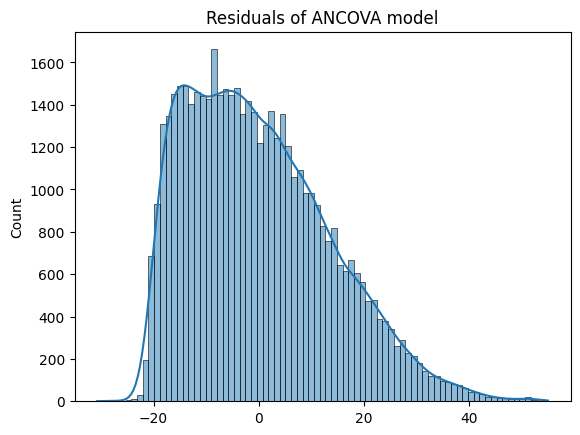

In [ ]:

# Check residuals
residuals = model.resid
sns.histplot(residuals, kde=True)
plt.title("Residuals of ANCOVA model")
plt.show()
